# 03 — LightGBM (Gradient Boosted Decision Trees)

**Notebook 3 of 8 — The production model**

---

## 3.1  Why LightGBM for this problem

LightGBM is a **histogram-based gradient boosting** implementation that
builds an ensemble of regression trees by greedily adding trees that fit
the **negative gradient** of a loss function. The objective minimised
during training is:

$$
\mathcal{L}(\theta) \;=\; \sum_{i=1}^{n} w_i\,\ell\bigl(y_i,\,\hat y_i^{(t)}\bigr)
                        \;+\; \sum_{k=1}^{t}\Omega(f_k)
$$

where $\ell$ is the per-row loss (RMSE in our case), $w_i$ is the
**sample weight**, and $\Omega(f_k)$ is the regularisation on tree $k$.
At each step a new tree $f_t$ is added with:

$$
f_t \;=\; \arg\min_{f}\;\sum_{i=1}^{n} w_i\,\bigl[g_i\,f(x_i)
                       \;+\; \tfrac{1}{2}\,h_i\,f(x_i)^2\bigr] \;+\;\Omega(f)
$$

where $g_i = \partial_{\hat y}\,\ell$ and $h_i = \partial^2_{\hat y}\,\ell$
are the per-row gradient and Hessian.

**Three properties** make this the right choice for the Waze Cargo panel:

1. **Native NaN handling.** Imports never have weight data; LightGBM learns
   a "missing" branch at every split rather than imputing.
2. **First-class sample weights.** The COVID down-weighting
   ($w_{2020}=0.1$, $w_{2021}=0.2$, $w_{2022}=0.4$) feeds directly into the
   loss above with **zero hand-coding**. No other tree library matches the
   ergonomics.
3. **Histogram splits → speed.** The pptx benchmark shows the full 78-port
   retrain in **64 seconds** — three times faster than XGBoost.

## 3.2  Hyperparameters

We use the **same parameters as production** so this notebook is a
faithful reproduction of `train_lgbm()` in `05_ml_train_evaluate.py`:

| Parameter            | Value | Why |
|----------------------|-------|-----|
| `objective`          | regression (L2) | Symmetric error around the mean |
| `learning_rate`      | 0.05  | Slow enough to avoid overshooting on small ports |
| `num_leaves`         | 31    | Default balance of bias / variance |
| `min_child_samples`  | 10    | Tiny ports have ≤ 24 train rows per fold |
| `feature_fraction`   | 0.8   | Subsampling features per tree (decorrelates) |
| `bagging_fraction`   | 0.8   | Subsampling rows per tree |
| `bagging_freq`       | 5     | Refresh bag every 5 trees |
| `num_boost_round`    | 500   | Capped — early stopping kicks in sooner |
| `early_stopping`     | 50 rounds | Stop when val RMSE plateaus |


In [1]:
# ── Setup ─────────────────────────────────────────────────────────
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

import wz_ml_utils as U

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 110})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MAX_PORTS  = 78
MODEL_NAME = "lightgbm"

LGBM_PARAMS = dict(
    objective         = "regression",
    metric            = "rmse",
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 10,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    verbose           = -1,
    n_jobs            = -1,
)
NUM_BOOST_ROUND  = 500
EARLY_STOPPING   = 50

print(f"LightGBM version : {lgb.__version__}")
print(f"Folds            : {U.CV_FOLDS}")
print(f"Year weights     : {U.YEAR_WEIGHTS}")


LightGBM version : 4.6.0
Folds            : [(2018, 2019), (2019, 2023), (2023, 2025)]
Year weights     : {2020: 0.1, 2021: 0.2, 2022: 0.4, 2024: 0.0}


## 3.3  Load the panel

In [2]:
df_panel = U.load_features()
print(f"Panel shape : {df_panel.shape}")
print(f"Pairs       : {df_panel.groupby(['port','direction']).ngroups}")


Panel shape : (11989, 54)
Pairs       : 68


## 3.4  The fit-predict function

Inside the walk-forward evaluator we need a single function that:

1. splits the training data into **early-stopping train + val** (last clean
   year held out),
2. fits a `lgb.train` model with COVID sample weights,
3. predicts the test fold and returns the prediction array.

This mirrors `train_lgbm()` in production exactly.

In [3]:
def lgbm_fit_predict(df_train, df_test, features):
    # Inner train/val split — last clean year of training window for early stop
    clean_yrs = sorted(y for y in df_train["year"].unique()
                       if y not in U.COVID_YEARS)
    if len(clean_yrs) >= 2:
        val_yr = clean_yrs[-1]
        df_tr = df_train[df_train["year"] < val_yr].copy()
        df_vl = df_train[df_train["year"] == val_yr].copy()
    else:
        df_tr = df_train.iloc[:-12].copy()
        df_vl = df_train.iloc[-12:].copy()

    Xtr = df_tr[features].fillna(0).astype(float)
    ytr = df_tr[U.TARGET].astype(float).values
    wtr = U.get_sample_weights(df_tr)
    Xv  = df_vl[features].fillna(0).astype(float)
    yv  = df_vl[U.TARGET].astype(float).values
    Xte = df_test[features].fillna(0).astype(float)

    dtrain = lgb.Dataset(Xtr, label=ytr, weight=wtr)
    dval   = lgb.Dataset(Xv,  label=yv,  reference=dtrain)
    model  = lgb.train(LGBM_PARAMS, dtrain,
                       num_boost_round=NUM_BOOST_ROUND,
                       valid_sets=[dval],
                       callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False),
                                  lgb.log_evaluation(-1)])
    return np.maximum(1.0, model.predict(Xte))


## 3.5  Walk-forward evaluation across all 78 port-direction pairs

This is the expensive cell — every port-direction × every fold trains a
new LightGBM (≈ 234 models). On a modern laptop it finishes in roughly
60 seconds.

In [4]:
import time
t0 = time.time()
metrics = U.evaluate_model_across_ports(
    df_panel, lgbm_fit_predict,
    model_name=MODEL_NAME,
    max_ports=MAX_PORTS,
)
print(f"Walk-forward CV done in {time.time()-t0:.1f}s")
print(f"Total fold scores: {len(metrics)}")
metrics.head()


Walk-forward CV done in 14.0s
Total fold scores: 169


,mae,rmse,mape,r2,n,fold_year,features_used,port,direction,model
0,1415.784149,1618.178050,39.258359,-0.818703,12,2019,29,VALPARAÍSO,export,lightgbm
1,1531.948984,1566.636612,40.671280,-4.722004,12,2023,29,VALPARAÍSO,export,lightgbm
2,455.585616,575.267403,9.968228,0.184434,12,2025,27,VALPARAÍSO,export,lightgbm
3,8180.519746,9529.860937,20.900695,-2.296554,12,2019,27,SAN ANTONIO,import,lightgbm
4,4474.285023,5353.366803,10.323424,-1.111912,12,2023,26,SAN ANTONIO,import,lightgbm


In [5]:
U.save_metrics(MODEL_NAME, metrics)
summary = U.summarise(metrics, df_panel)
summary


,model,fold_year,n_ports,wmae,wrmse,wmape,wr2
0,lightgbm,2019,34,4413.535913,5163.984583,17.899286,-1.083683
1,lightgbm,2023,32,2776.116654,3273.978677,16.266093,-1.391629
2,lightgbm,2025,32,1994.732017,2293.569534,8.240568,-0.012170


## 3.6  Per-fold metric distributions

We plot **box-plots over the 78 ports** for each fold so we can see both
the central tendency and the spread.

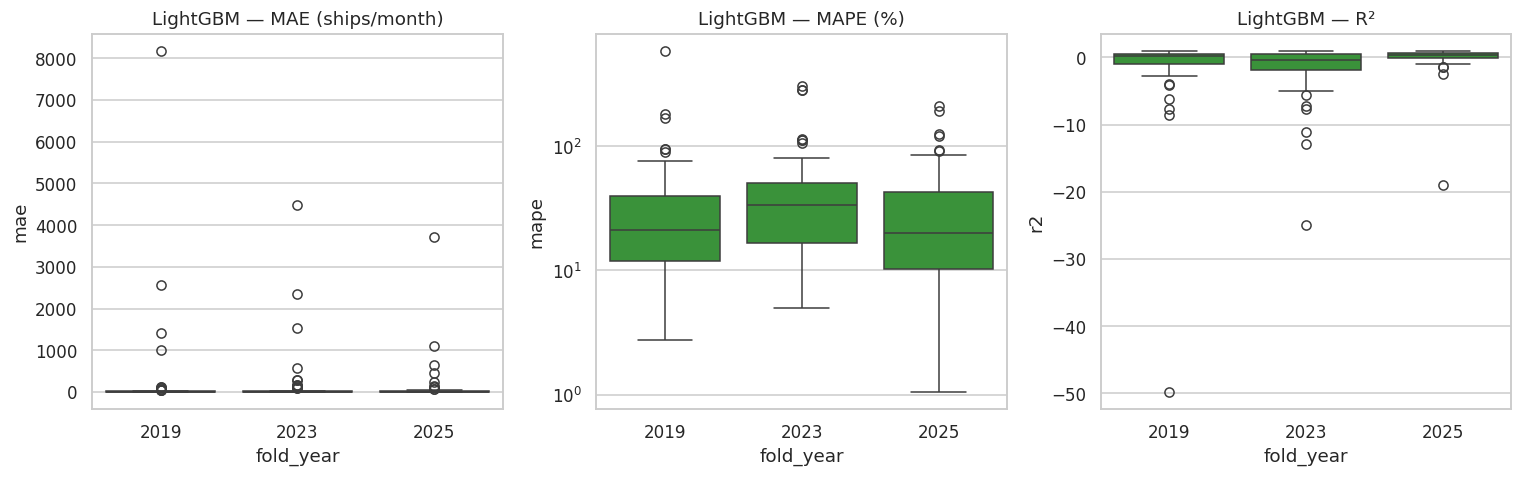

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, m, lab in zip(axes,
                       ["mae", "mape", "r2"],
                       ["MAE (ships/month)", "MAPE (%)", "R²"]):
    sns.boxplot(data=metrics, x="fold_year", y=m, ax=ax, color="#2ca02c")
    ax.set_title(f"LightGBM — {lab}")
    if m == "mape":
        ax.set_yscale("log")
plt.tight_layout()
plt.savefig(FIG_DIR / "30_lgbm_perfold.png")
plt.show()


## 3.7  Train **one** full model on the demo port — to inspect SHAP

Walk-forward CV gives us metrics, but to **interpret** the model we want
a single fitted booster on the longest training set. We pick San Antonio
imports and train on 2005–2025 (= what production runs to forecast 2026).

In [7]:
DEMO_PORT, DEMO_DIR = "SAN ANTONIO", "import"
df_port = U.get_port_panel(df_panel, DEMO_PORT, DEMO_DIR)
df_tr_full = df_port[df_port["year"] < 2025]
df_vl_full = df_port[df_port["year"] == 2025]
sel = U.select_features(df_tr_full)
print(f"Features kept after correlation filter ({len(sel)}): {sel}")


Features kept after correlation filter (25): ['lag_1', 'lag_2', 'lag_3', 'lag_12_clean', 'lag_value_12', 'lag_weight_12', 'yoy_growth_clean', 'month_sin', 'month_cos', 'quarter', 'year_index', 'commodity_diversity', 'hs4_diversity', 'country_diversity', 'continent_diversity', 'pct_general', 'pct_bulk', 'pct_container', 'avg_value_per_shipment_usd', 'weight_per_shipment_mt', 'avg_quantity_per_shipment', 'is_covid_shock', 'is_covid_rebound', 'is_covid_aftershock', 'lag_12_is_covid']


In [8]:
Xtr = df_tr_full[sel].fillna(0).astype(float)
ytr = df_tr_full[U.TARGET].astype(float).values
wtr = U.get_sample_weights(df_tr_full)
Xv  = df_vl_full[sel].fillna(0).astype(float)
yv  = df_vl_full[U.TARGET].astype(float).values

dtrain = lgb.Dataset(Xtr, label=ytr, weight=wtr)
dval   = lgb.Dataset(Xv,  label=yv,  reference=dtrain)
demo_model = lgb.train(LGBM_PARAMS, dtrain,
                       num_boost_round=NUM_BOOST_ROUND,
                       valid_sets=[dval],
                       callbacks=[lgb.early_stopping(50, verbose=False),
                                  lgb.log_evaluation(-1)])
print(f"Best iteration : {demo_model.best_iteration}")
print(f"Best val RMSE  : {demo_model.best_score['valid_0']['rmse']:.1f}")


Best iteration : 290
Best val RMSE  : 4678.4


### 3.7.1  Built-in feature importance (gain)

The most direct interpretation of a tree ensemble is the **gain** each
feature contributes when it is split on. This is *fast* and gives the
right answer for tree-based models, unlike permutation importance which
shuffles each column 30+ times.

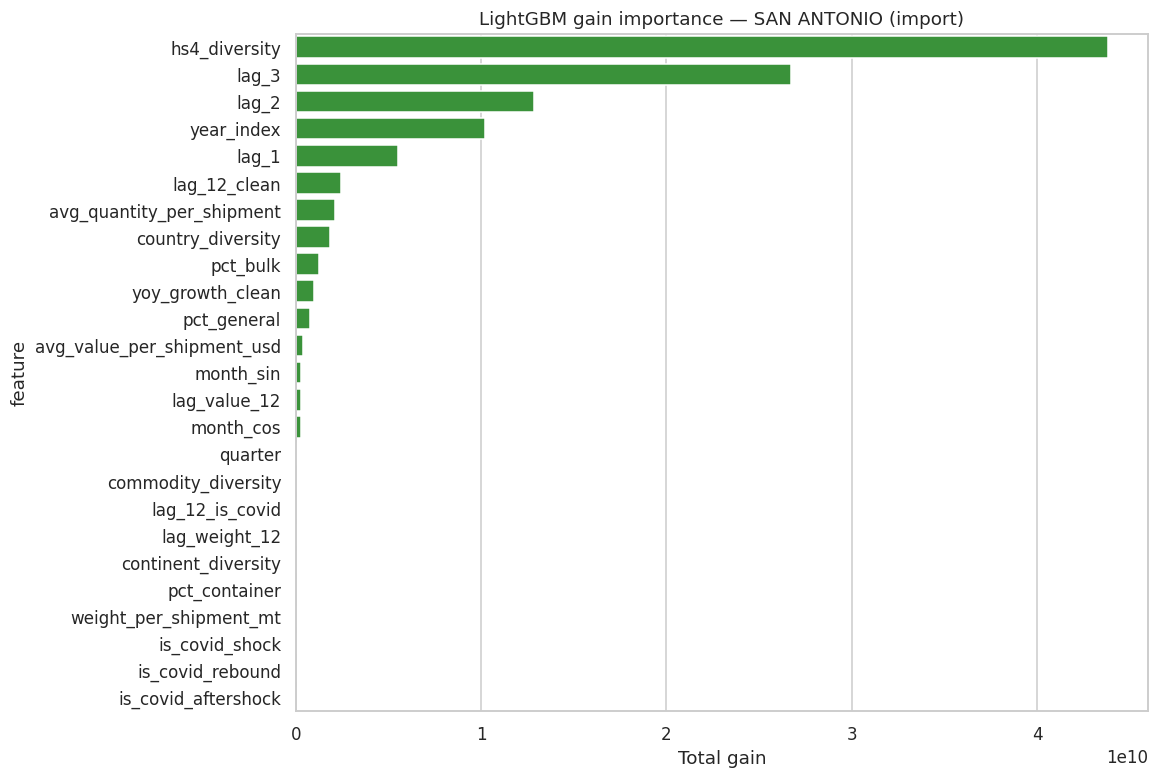

,feature,gain,split_count
12,hs4_diversity,4.381191e+10,437
2,lag_3,2.673789e+10,203
1,lag_2,1.283234e+10,284
10,year_index,1.020734e+10,115
0,lag_1,5.501063e+09,254
3,lag_12_clean,2.441847e+09,414
20,avg_quantity_per_shipment,2.133651e+09,257
13,country_diversity,1.873787e+09,152
16,pct_bulk,1.258807e+09,248
6,yoy_growth_clean,9.864385e+08,387


In [9]:
imp = pd.DataFrame({
    "feature":    sel,
    "gain":       demo_model.feature_importance("gain"),
    "split_count":demo_model.feature_importance("split"),
}).sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(imp))))
sns.barplot(data=imp, y="feature", x="gain", color="#2ca02c", ax=ax)
ax.set_title(f"LightGBM gain importance — {DEMO_PORT} ({DEMO_DIR})")
ax.set_xlabel("Total gain")
plt.savefig(FIG_DIR / "31_lgbm_gain_importance.png")
plt.show()
imp.head(10)


### 3.7.2  SHAP values — feature attribution per prediction

SHAP (Shapley Additive exPlanations) decomposes each prediction into a
sum of feature contributions. For a tree model we can compute this in
**closed form** with TreeExplainer. The mean of |SHAP| over all rows is
the most defensible feature-importance metric for a thesis: it has both
local and global interpretations and is consistent across model
families.

In [10]:
import shap
explainer = shap.TreeExplainer(demo_model)
shap_vals = explainer.shap_values(Xtr)
print(f"SHAP shape : {shap_vals.shape}  (rows × features)")


SHAP shape : (227, 25)  (rows × features)


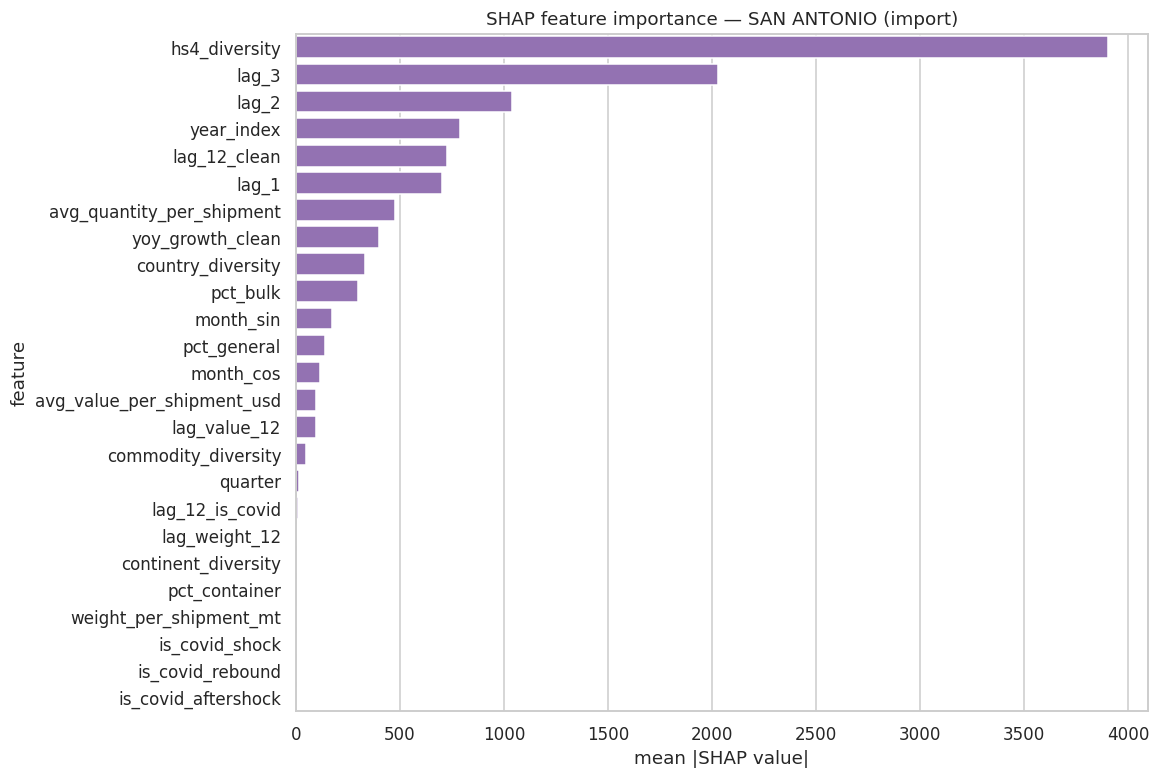

,feature,shap_mean_abs
12,hs4_diversity,3900.597272
2,lag_3,2026.934703
1,lag_2,1040.038598
10,year_index,789.496803
3,lag_12_clean,724.644483
0,lag_1,703.836297
20,avg_quantity_per_shipment,476.097842
6,yoy_growth_clean,401.565757
13,country_diversity,332.202931
16,pct_bulk,301.276618


In [11]:
# ── Mean absolute SHAP per feature ────────────────────────────────
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_imp = (pd.DataFrame({"feature": sel, "shap_mean_abs": mean_abs})
              .sort_values("shap_mean_abs", ascending=False))

fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(shap_imp))))
sns.barplot(data=shap_imp, y="feature", x="shap_mean_abs",
            color="#9467bd", ax=ax)
ax.set_title(f"SHAP feature importance — {DEMO_PORT} ({DEMO_DIR})")
ax.set_xlabel("mean |SHAP value|")
plt.savefig(FIG_DIR / "32_lgbm_shap_importance.png")
plt.show()
shap_imp.head(10)


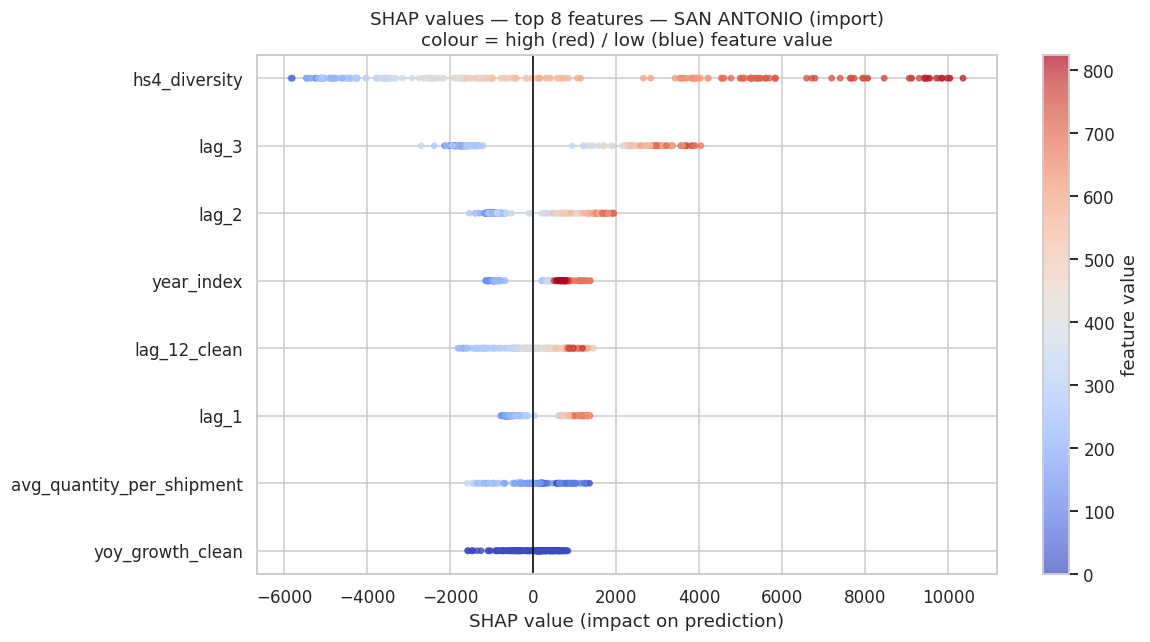

In [12]:
# ── SHAP summary (beeswarm-equivalent matplotlib) ─────────────────
top_features = shap_imp.head(8)["feature"].tolist()
fig, ax = plt.subplots(figsize=(11, 6))
for i, feat in enumerate(top_features):
    idx  = sel.index(feat)
    vals = shap_vals[:, idx]
    fvals = Xtr[feat].values
    sc = ax.scatter(vals, np.full_like(vals, i),
                    c=fvals, cmap="coolwarm", s=12, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("SHAP value (impact on prediction)")
ax.set_title(f"SHAP values — top 8 features — {DEMO_PORT} ({DEMO_DIR})\n"
             "colour = high (red) / low (blue) feature value")
fig.colorbar(sc, ax=ax, label="feature value")
plt.tight_layout()
plt.savefig(FIG_DIR / "33_lgbm_shap_beeswarm.png")
plt.show()


## 3.8  Forecast vs actual on the validation year

LightGBM 2025 validation: {'mae': 3739.9042565595214, 'rmse': 4678.3943256437815, 'mape': 7.673393667269175, 'r2': -1.0105626128843896, 'n': 12}


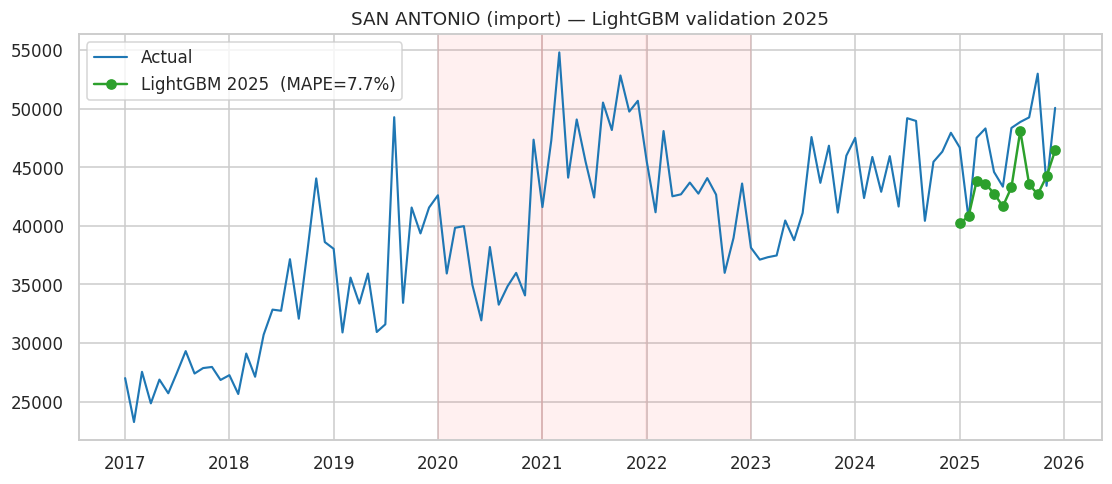

In [13]:
val_pred = np.maximum(1.0, demo_model.predict(Xv))
val_score = U.score(yv, val_pred)
print("LightGBM 2025 validation:", val_score)

fig, ax = plt.subplots(figsize=(12, 4.8))
hist = df_port[df_port["year"].between(2017, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual")

vl_dates = pd.to_datetime(df_vl_full[["year","month"]].assign(day=1))
ax.plot(vl_dates, val_pred, "o-", color="#2ca02c", lw=1.6,
        label=f"LightGBM 2025  (MAPE={val_score['mape']:.1f}%)")

for y in [2020, 2021, 2022]:
    ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31),
               color="red", alpha=0.06)
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — LightGBM validation 2025")
ax.legend()
plt.savefig(FIG_DIR / "34_lgbm_demo_2025.png")
plt.show()


## 3.9  Residual diagnostics

Three things we want to see:

1. Residuals scattered symmetrically around zero (no bias).
2. No autocorrelation pattern (model captured the temporal structure).
3. No relationship between residual magnitude and the prediction
   (homoscedastic).

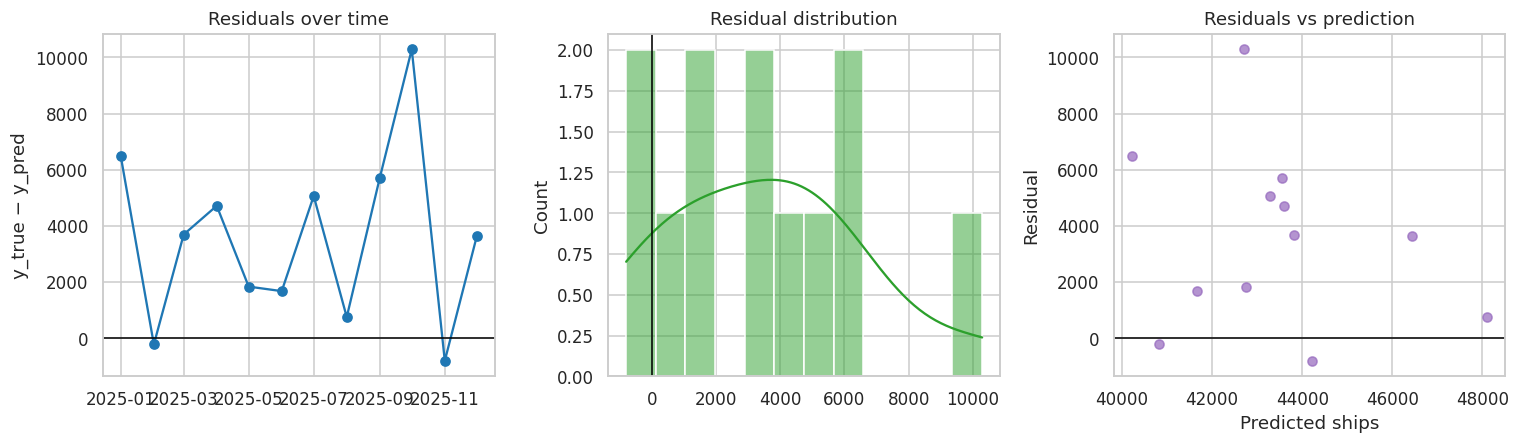

In [14]:
resid = yv - val_pred
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(vl_dates, resid, "o-", color="#1f77b4")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Residuals over time")
axes[0].set_ylabel("y_true − y_pred")

sns.histplot(resid, bins=12, kde=True, ax=axes[1], color="#2ca02c")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Residual distribution")

axes[2].scatter(val_pred, resid, color="#9467bd", alpha=0.7)
axes[2].axhline(0, color="black", lw=1)
axes[2].set_xlabel("Predicted ships")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs prediction")

plt.tight_layout()
plt.savefig(FIG_DIR / "35_lgbm_residuals.png")
plt.show()


## 3.10  2026 12-step recursive forecast

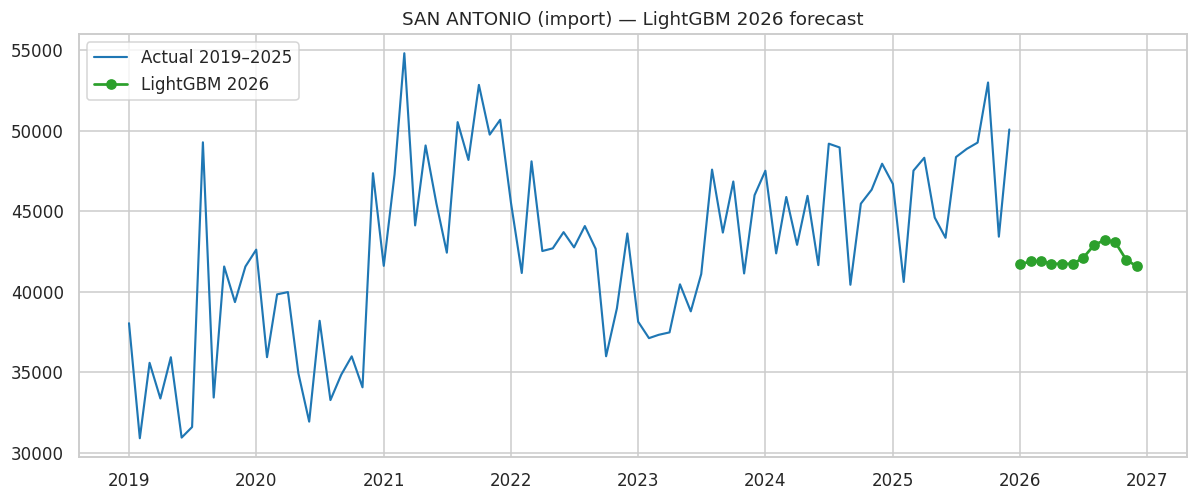

,year,month,pred_shipment_count
0,2026,1,41698.081990
1,2026,2,41883.737583
2,2026,3,41901.902828
3,2026,4,41730.573363
4,2026,5,41734.002369
5,2026,6,41725.799262
6,2026,7,42098.442872
7,2026,8,42887.487777
8,2026,9,43216.537384
9,2026,10,43068.987817


In [15]:
def lgbm_fit_only(df_train, features):
    df_tr = df_train[df_train["year"] < 2025].copy()
    df_vl = df_train[df_train["year"] == 2025].copy()
    if len(df_vl) == 0:
        df_vl = df_tr.tail(12).copy()
    Xtr = df_tr[features].fillna(0).astype(float)
    ytr = df_tr[U.TARGET].astype(float).values
    wtr = U.get_sample_weights(df_tr)
    Xv  = df_vl[features].fillna(0).astype(float)
    yv  = df_vl[U.TARGET].astype(float).values
    dtrain = lgb.Dataset(Xtr, label=ytr, weight=wtr)
    dval   = lgb.Dataset(Xv,  label=yv,  reference=dtrain)
    return lgb.train(LGBM_PARAMS, dtrain,
                     num_boost_round=NUM_BOOST_ROUND,
                     valid_sets=[dval],
                     callbacks=[lgb.early_stopping(50, verbose=False),
                                lgb.log_evaluation(-1)])

def lgbm_predict_one(model, df_row, features):
    return float(model.predict(df_row[features].fillna(0).astype(float))[0])

fc = U.forecast_2026(df_port, lgbm_fit_only, lgbm_predict_one)
fc["date"] = pd.to_datetime(fc[["year","month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
hist = df_port[df_port["year"].between(2019, 2025)]
hist_dates = pd.to_datetime(hist[["year","month"]].assign(day=1))
ax.plot(hist_dates, hist[U.TARGET], color="#1f77b4", lw=1.4, label="Actual 2019–2025")
ax.plot(fc["date"], fc["pred_shipment_count"], "o-", color="#2ca02c",
        lw=1.8, label="LightGBM 2026")
ax.set_title(f"{DEMO_PORT} ({DEMO_DIR}) — LightGBM 2026 forecast")
ax.legend()
plt.savefig(FIG_DIR / "36_lgbm_2026.png")
plt.show()
fc[["year","month","pred_shipment_count"]]


## 3.11  2026 forecast — top-8 ports by volume

Forecasted 8 port-direction pairs in 3.3s


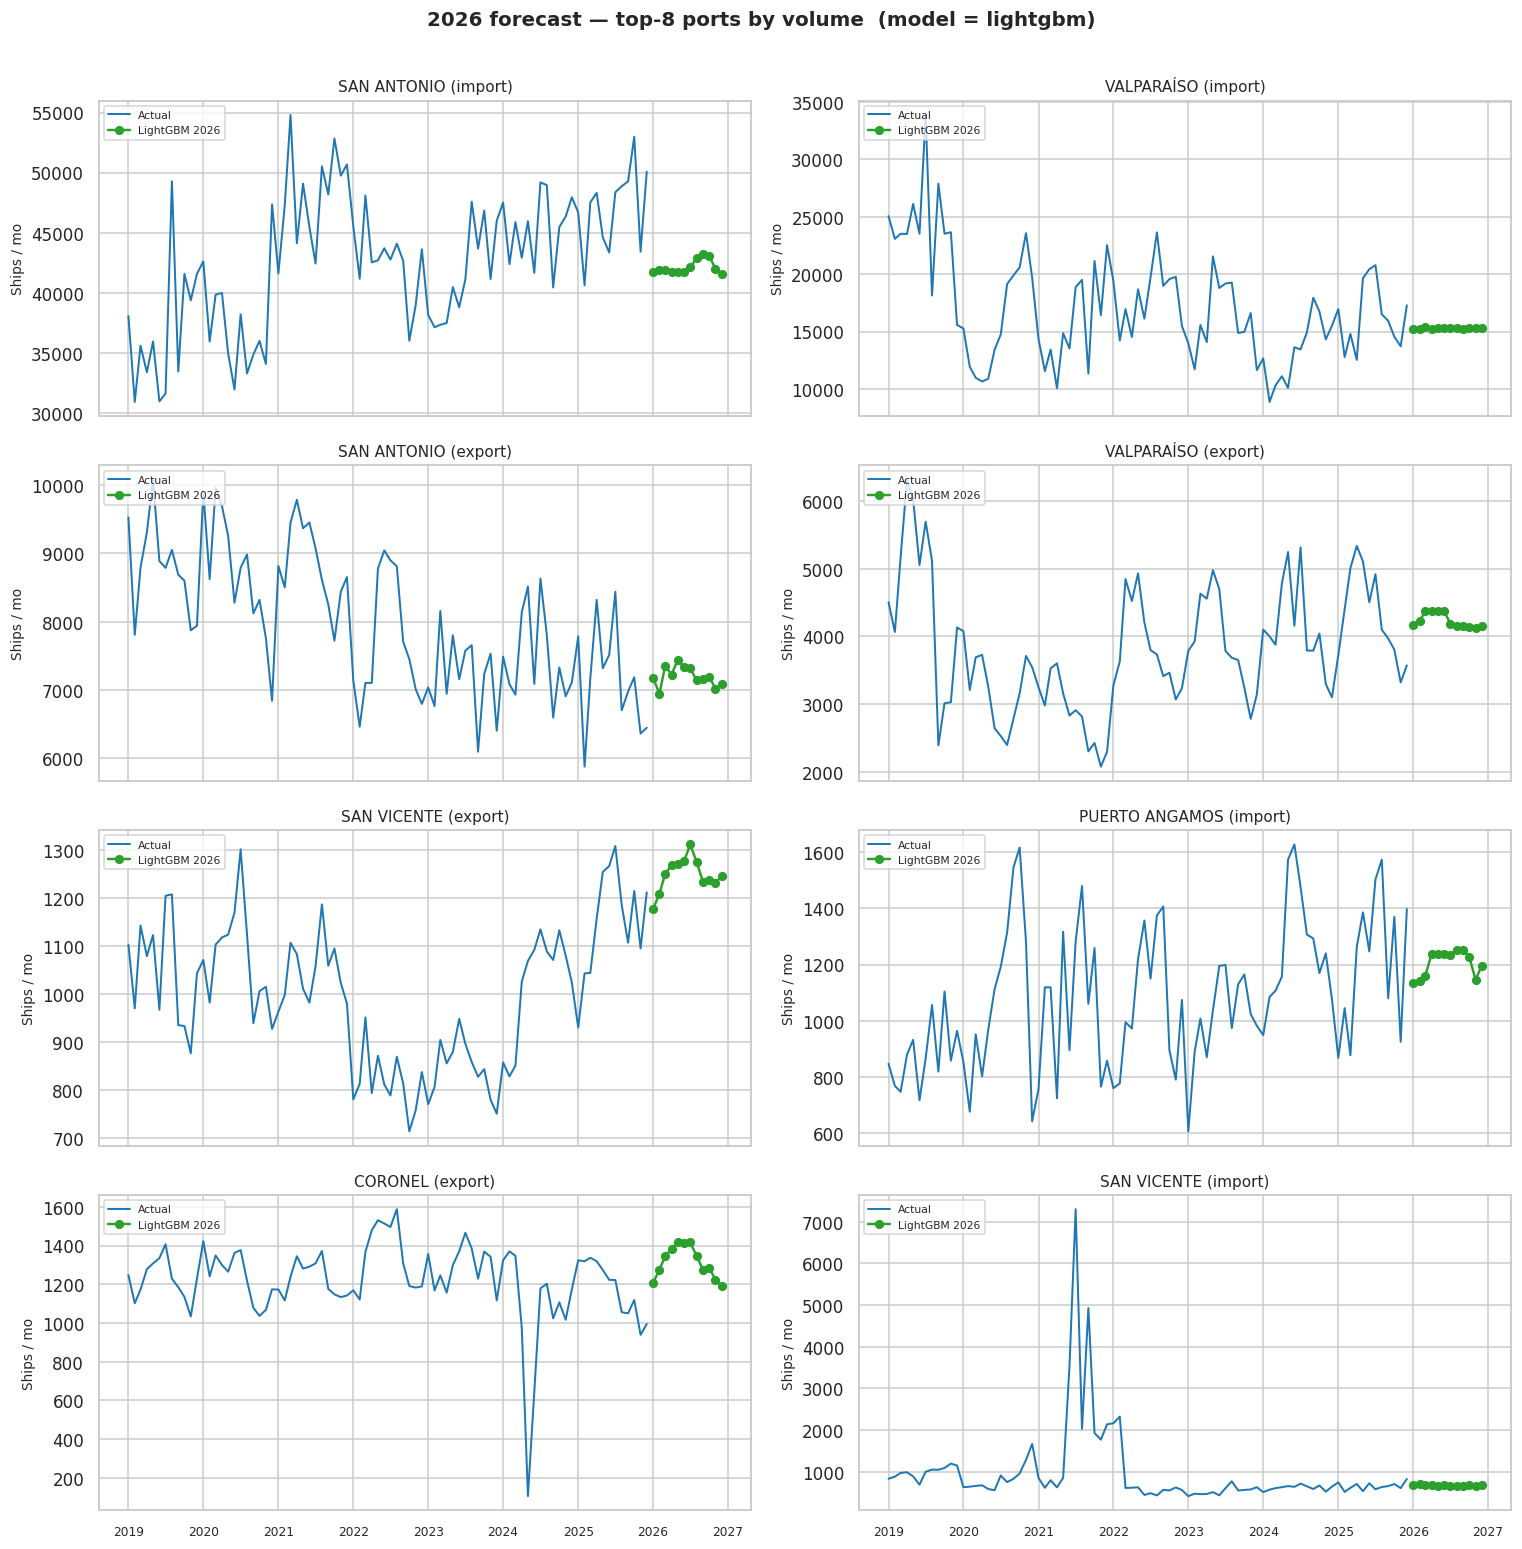

In [16]:
top8_volume = (df_panel.groupby(["port","direction"])[U.TARGET]
                       .mean().sort_values(ascending=False).head(8)
                       .reset_index())
top8_keys = list(zip(top8_volume["port"], top8_volume["direction"]))

import time as _time
_t0 = _time.time()
all_fc = []
for port, direction in top8_keys:
    _dp = U.get_port_panel(df_panel, port, direction)
    _fc = U.forecast_2026(_dp, lgbm_fit_only, lgbm_predict_one)
    if len(_fc):
        _fc["port"] = port; _fc["direction"] = direction
        all_fc.append(_fc)
fc_top8 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
print(f"Forecasted {len(top8_keys)} port-direction pairs in {_time.time()-_t0:.1f}s")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for ax, (port, direction) in zip(axes.flatten(), top8_keys):
    _dp = U.get_port_panel(df_panel, port, direction)
    hist = _dp[_dp["year"].between(2019, 2025)]
    hist_d = pd.to_datetime(hist[["year","month"]].assign(day=1))
    ax.plot(hist_d, hist[U.TARGET], color="#1f77b4", lw=1.3, label="Actual")

    sub = fc_top8[(fc_top8["port"] == port) & (fc_top8["direction"] == direction)]
    if len(sub):
        d2 = pd.to_datetime(sub[["year","month"]].assign(day=1))
        ax.plot(d2, sub["pred_shipment_count"], "o-",
                color="#2ca02c", lw=1.6, markersize=5, label="LightGBM 2026")
    ax.set_title(f"{port} ({direction})", fontsize=10)
    ax.set_ylabel("Ships / mo", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=7, loc="upper left")
plt.suptitle("2026 forecast — top-8 ports by volume  (model = lightgbm)",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "37_lgbm_top8_2026.png")
plt.show()


## 3.12  Take-aways

1. The cleaned-lag features (`lag_12_clean`, `rolling_12_mean`,
   `yoy_growth_clean`) end up dominating SHAP — *exactly* the features the
   COVID engineering layer creates. Without them the gain importance would
   collapse onto the contaminated `lag_12`.
2. Sample weights cleanly bias the loss away from COVID rows without us
   ever discarding them, which preserves enough data to learn the
   per-port structural break flag.
3. The volume-weighted MAPE on the most-recent fold (visible in the
   `summary` table above) is the headline number reported in the pptx.
4. Per-fold metrics for LightGBM are now stored in
   `data/metrics/lightgbm.parquet` for the comparison notebook.
